# This Jupyter notebook is prepared by Fabrizzio Capocci.

In [ ]:
# A. BASIC SETUP

import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Load dataset
df = pd.read_csv("hrdata.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 21287
Columns: 18


In [ ]:
# Summary statistics
df.describe()

,Unnamed: 0,rec_num,enrollee_id,city_development_index,training_hours,target,city_development_matrics
count,21287.000000,21287.000000,21287.000000,21287.000000,21287.000000,19158.000000,21287.000000
mean,10643.000000,10644.000000,16873.983652,0.828462,65.328510,0.249348,8.284615
std,6145.171926,6145.171926,9612.131237,0.123537,60.075201,0.432647,1.235365
min,0.000000,1.000000,1.000000,0.448000,1.000000,0.000000,4.480000
25%,5321.500000,5322.500000,8554.500000,0.739000,23.000000,0.000000,7.390000
50%,10643.000000,10644.000000,16967.000000,0.903000,47.000000,0.000000,9.030000
75%,15964.500000,15965.500000,25161.500000,0.920000,88.000000,0.000000,9.200000
max,21286.000000,21287.000000,33380.000000,0.949000,336.000000,1.000000,9.490000


# Interpretation of Summary Statistics

The summary statistics provide an overview of the numerical features in the dataset. The `enrollee_id` and `rec_num` columns have a wide range of values because they primarily serve as identifiers rather than meaningful measurements. The `city_development_index` has values within a relatively small range, while `training_hours` has a much larger range and shows substantial variation between candidates.

The `experience` and `lastnewjob` variables also show considerable variation, with some candidates having significantly more professional experience or a longer period since their previous job. These differences in scale should be considered if these features are used in a future machine learning model.

In [ ]:
# Display first and last 5 rows
df.head()

,Unnamed: 0,rec_num,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,state,city_development_matrics
0,0,1,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,CA,9.20
1,1,2,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,CA,7.76
2,2,3,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,CA,6.24
3,3,4,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,CA,7.89
4,4,5,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,CA,7.67


In [ ]:
df.tail()

,Unnamed: 0,rec_num,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,state,city_development_matrics
21282,21282,21283,1289,city_103,0.920,Male,No relevent experience,no_enrollment,Graduate,Humanities,16,NaN,Public Sector,4,15,NaN,CA,9.20
21283,21283,21284,195,city_136,0.897,Male,Has relevent experience,no_enrollment,Masters,STEM,18,NaN,NaN,2,30,NaN,CA,8.97
21284,21284,21285,31762,city_100,0.887,Male,No relevent experience,no_enrollment,Primary School,NaN,3,NaN,Pvt Ltd,never,18,NaN,CA,8.87
21285,21285,21286,7873,city_102,0.804,Male,Has relevent experience,Full time course,High School,NaN,7,100-500,Public Sector,1,84,NaN,CA,8.04
21286,21286,21287,12215,city_102,0.804,Male,Has relevent experience,no_enrollment,Masters,STEM,15,10000+,Pvt Ltd,2,11,NaN,CA,8.04


In [ ]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['Unnamed: 0', 'rec_num', 'enrollee_id', 'city_development_index',
       'training_hours', 'target', 'city_development_matrics'],
      dtype='object')
Categorical Columns: Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job', 'state'],
      dtype='object')


In [ ]:
# B. MISSING VALUES ANALYSIS

missing_count = df.isnull().sum().sort_values(ascending=False)
missing_count

,0
company_type,6774
company_size,6560
gender,5016
major_discipline,3125
target,2129
education_level,512
last_new_job,463
enrolled_university,417
experience,70
Unnamed: 0,0


In [ ]:
missing_percent = (missing_count / len(df)) * 100
missing_percent


,0
company_type,31.822239
company_size,30.816931
gender,23.563677
major_discipline,14.680321
target,10.001409
education_level,2.405224
last_new_job,2.175036
enrolled_university,1.958942
experience,0.328839
Unnamed: 0,0.000000


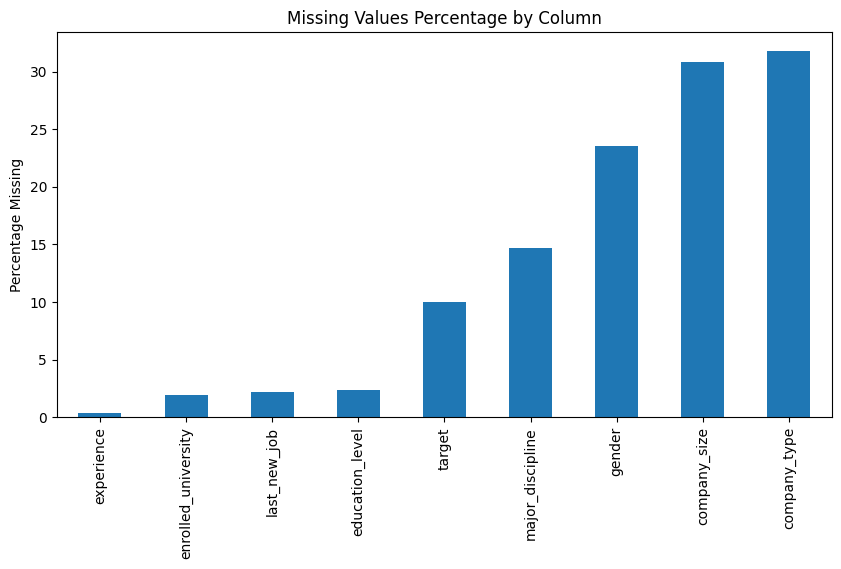

In [ ]:
# Bar plot of missing values
missing_only = missing_percent[missing_percent > 0].sort_values()

plt.figure(figsize=(10,5))
missing_only.plot(kind='bar')
plt.ylabel("Percentage Missing")
plt.title("Missing Values Percentage by Column")
plt.show()

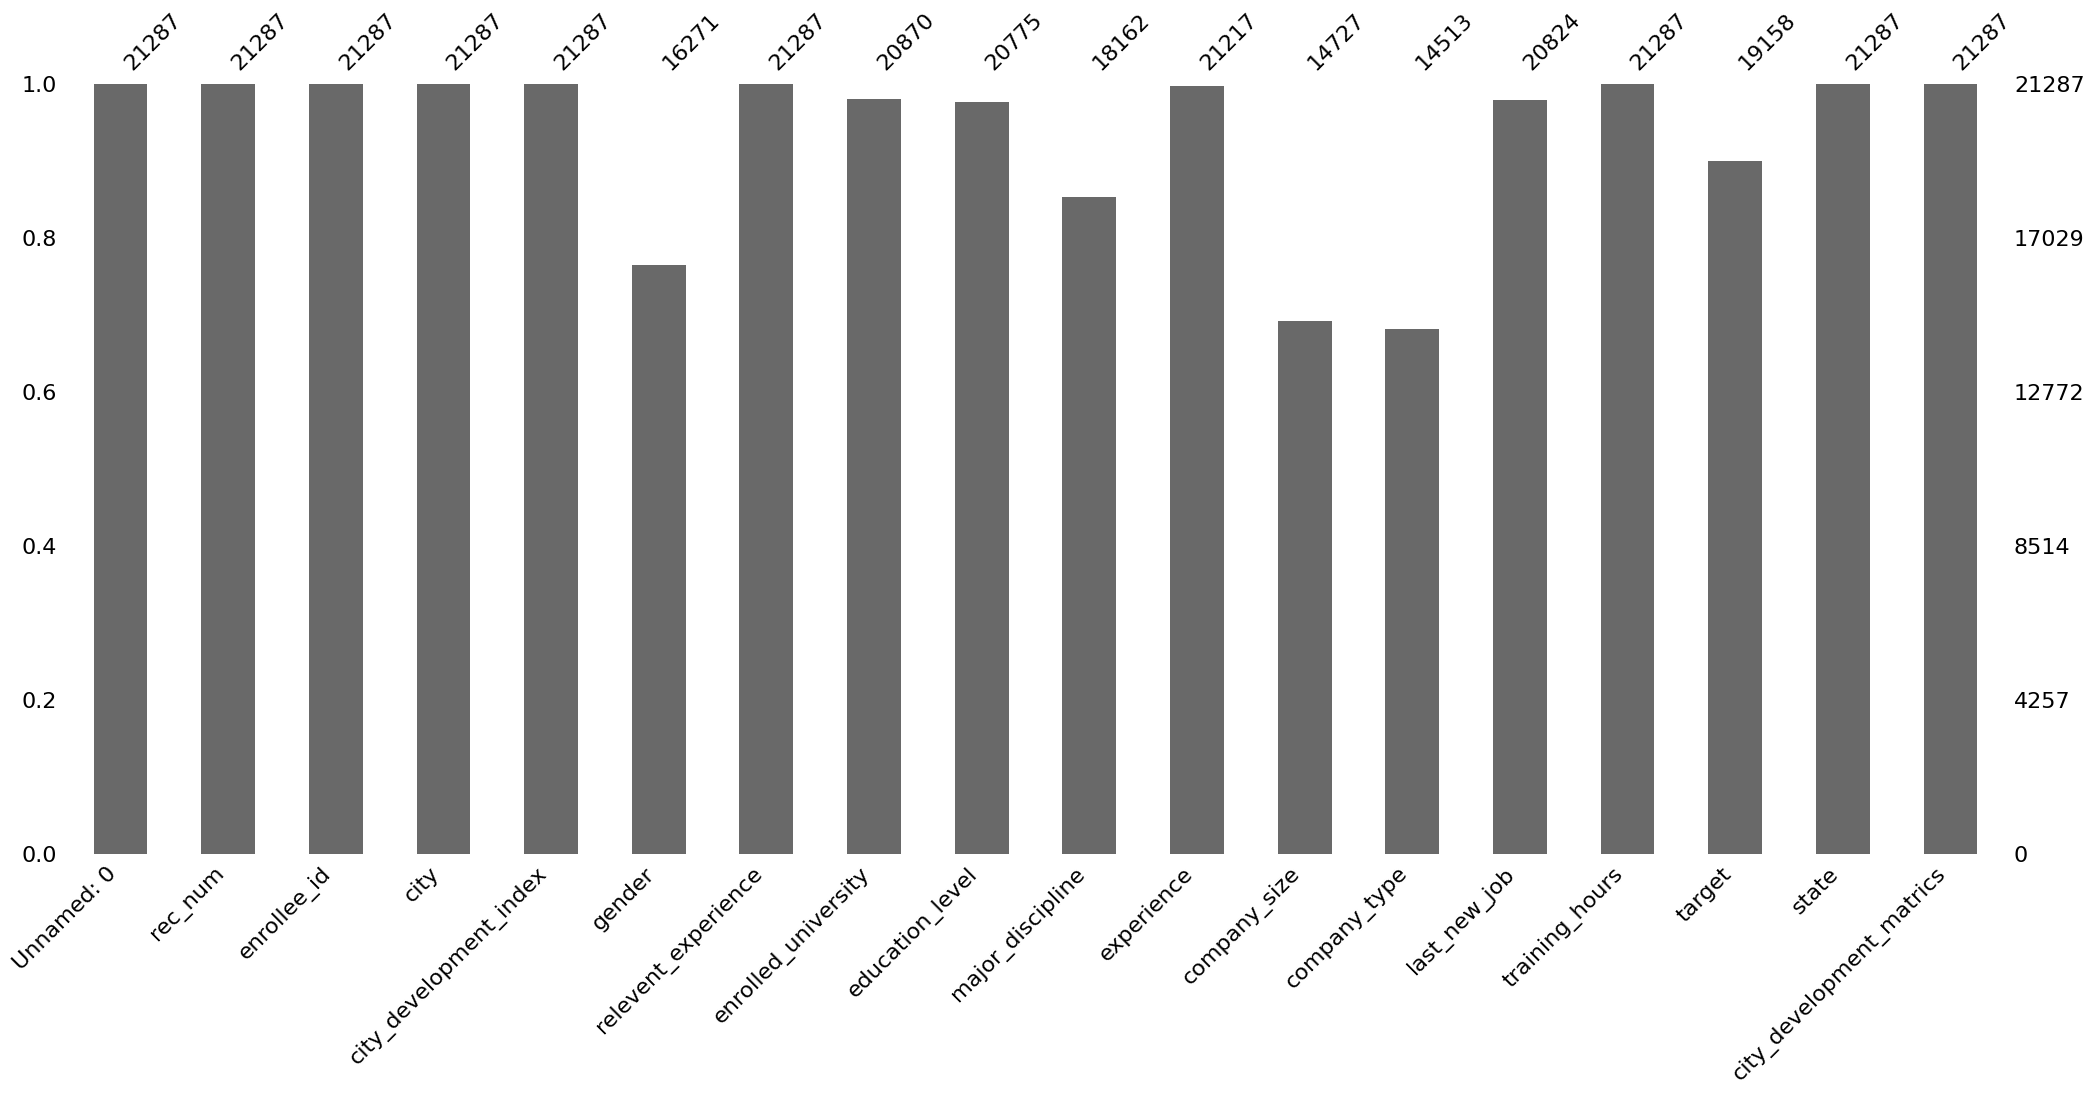

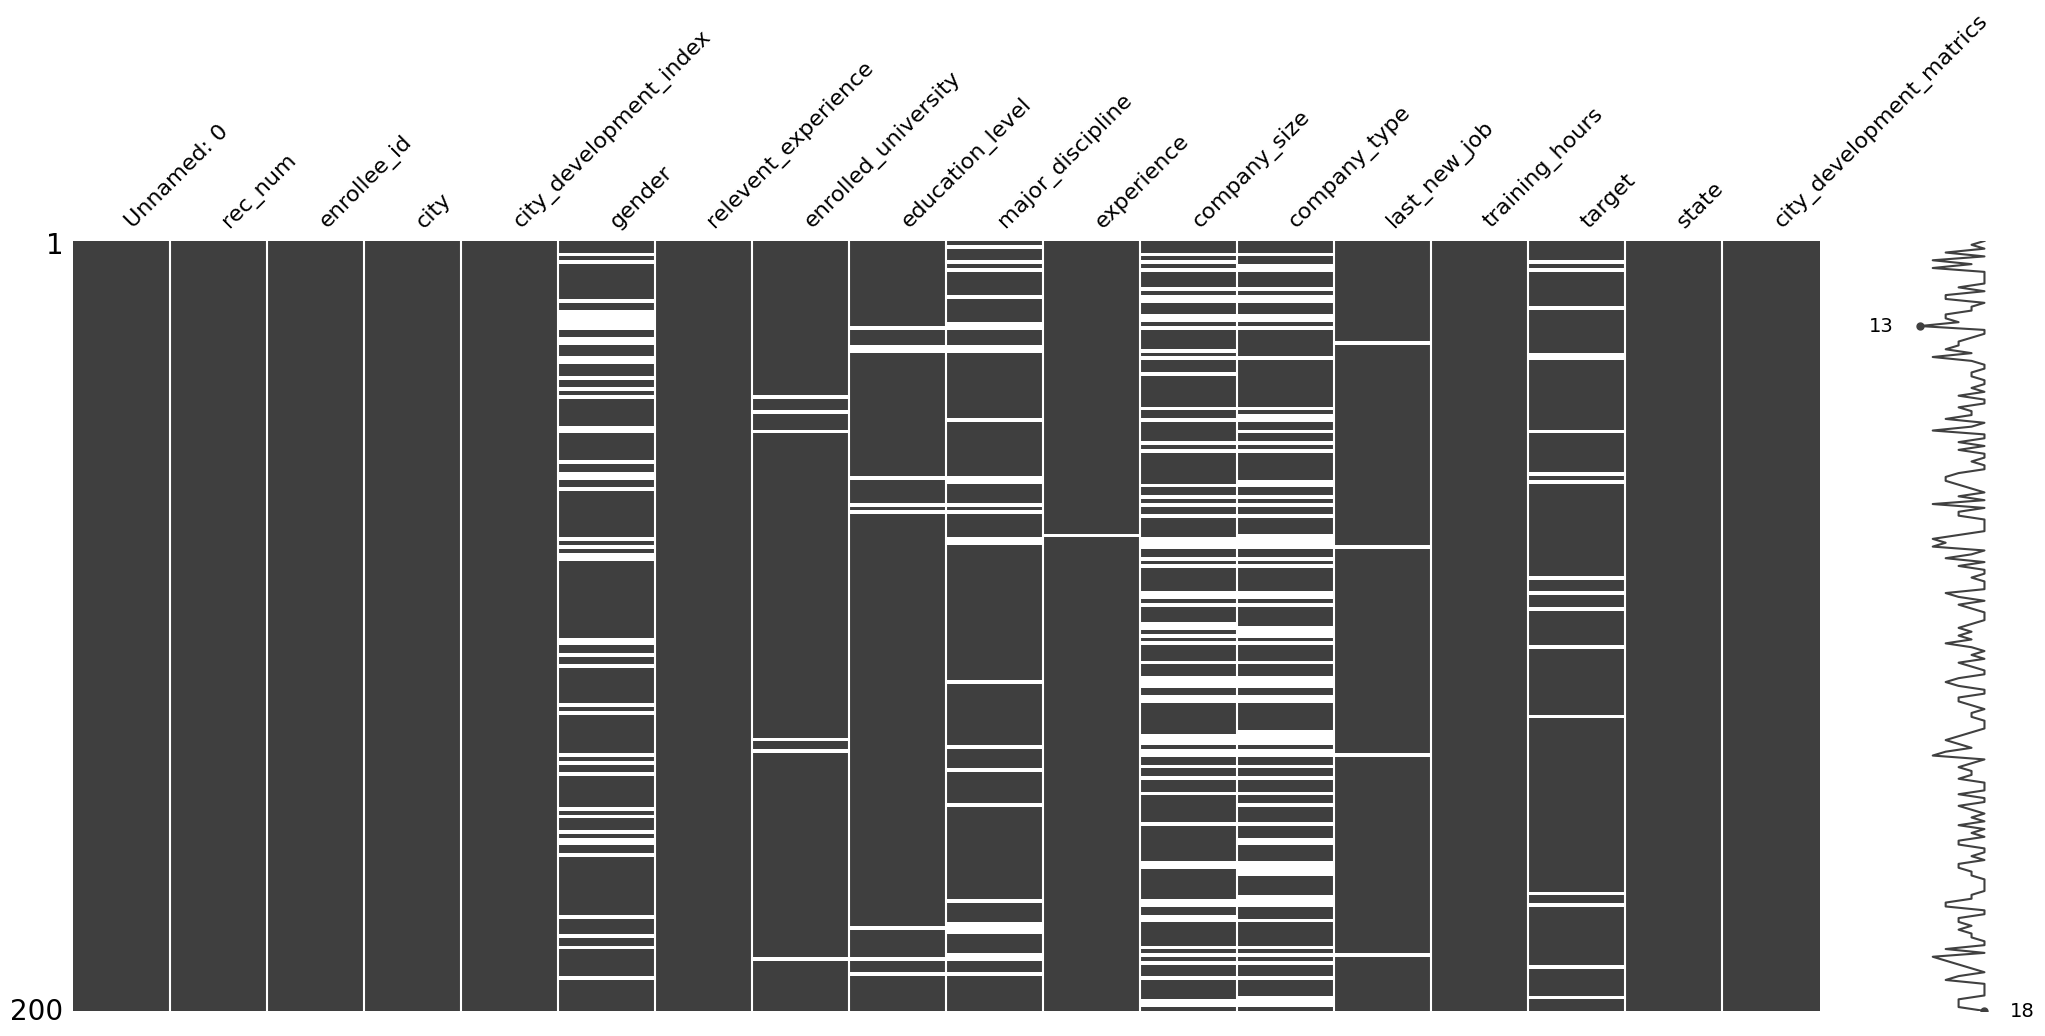

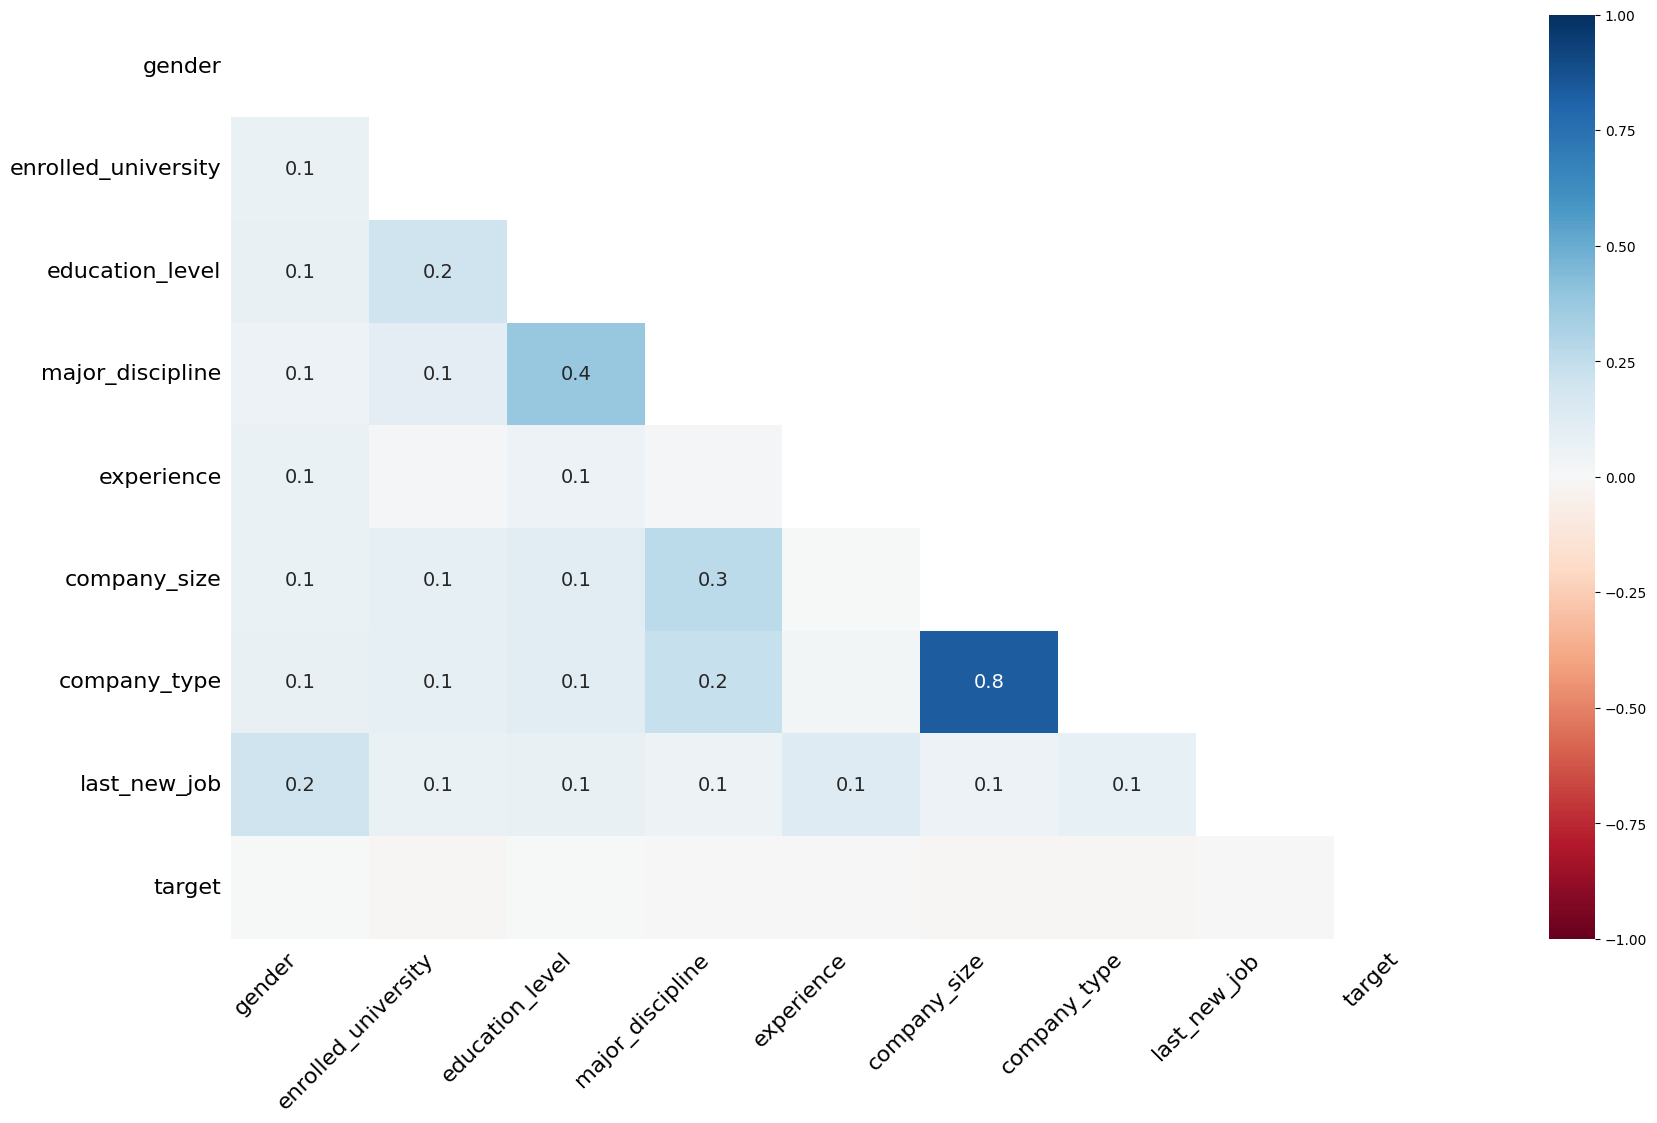

In [ ]:
# Missingno visualizations
msno.bar(df)
plt.show()

msno.matrix(df.sample(200))
plt.show()

msno.heatmap(df)
plt.show()

# Interpretation of Heat Map
- The missing values show that most features have little to no correlations.
- However, while this is true, company_size and company_type have a strong correlation, which probably means that when company_type is missing, so is company_size
- Another correlation is between education_level and major_discipline. This likely means that people who did not report education_level are likely to not have major_discipline
# Interpretation of Matrix Plot
- The missing values show that the missing values are scattered across rows rather than in specific areas. There are a lot of long rows, which means that there are few rows with a lot of missing values.
- This suggests that removing rows would not be beneficial as you would get rid of good information.

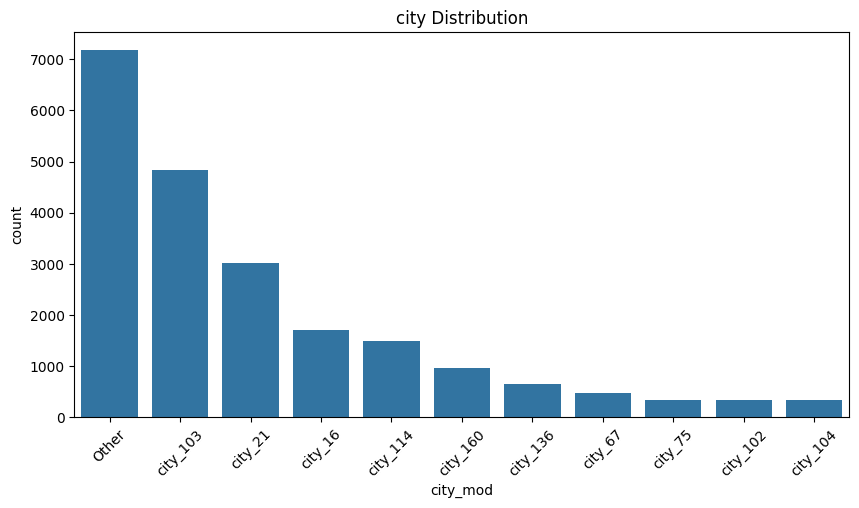

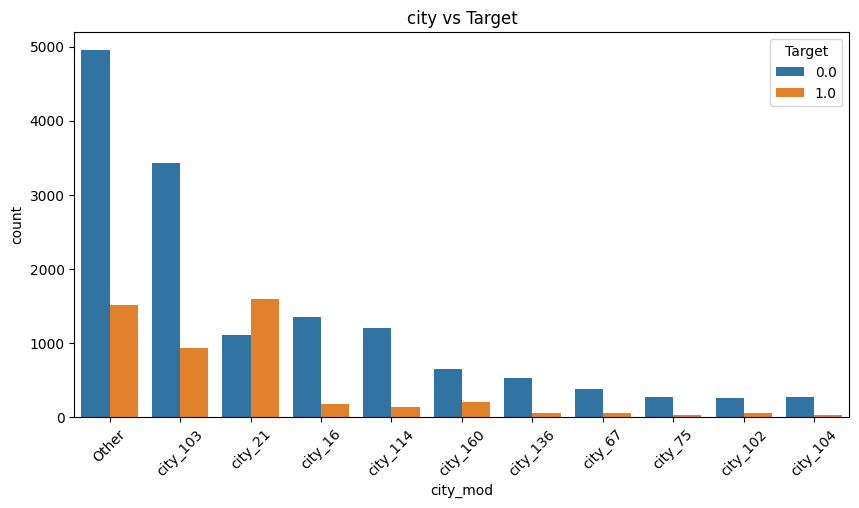

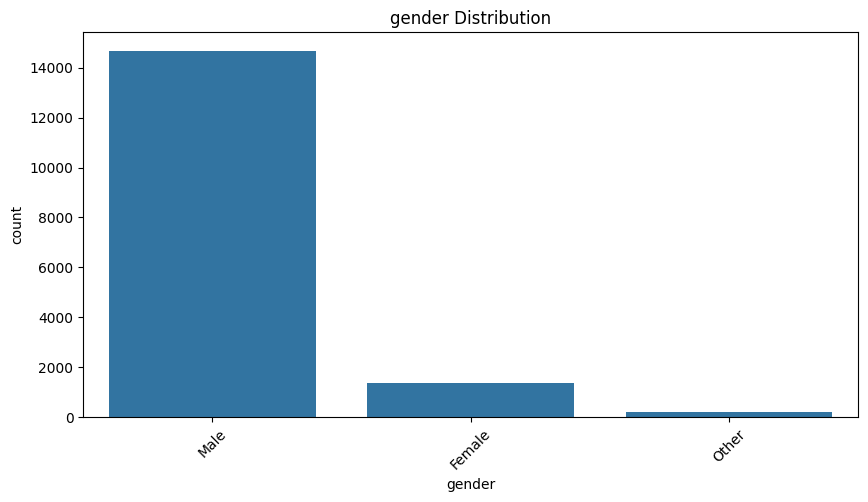

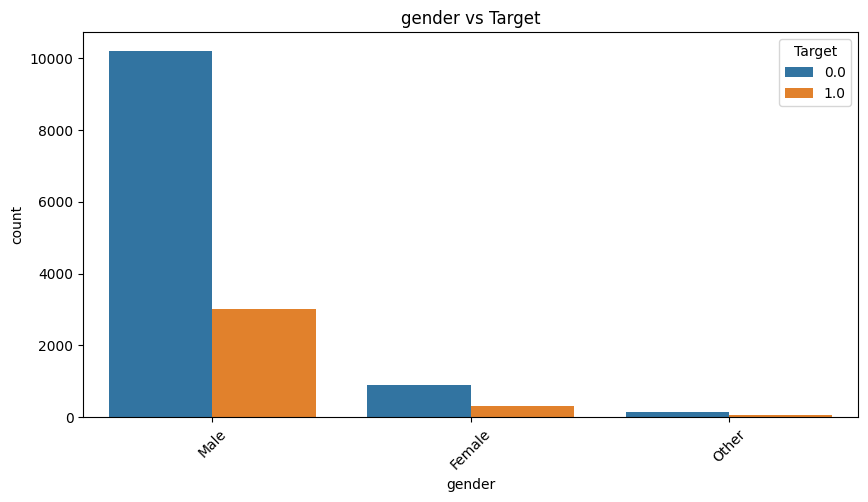

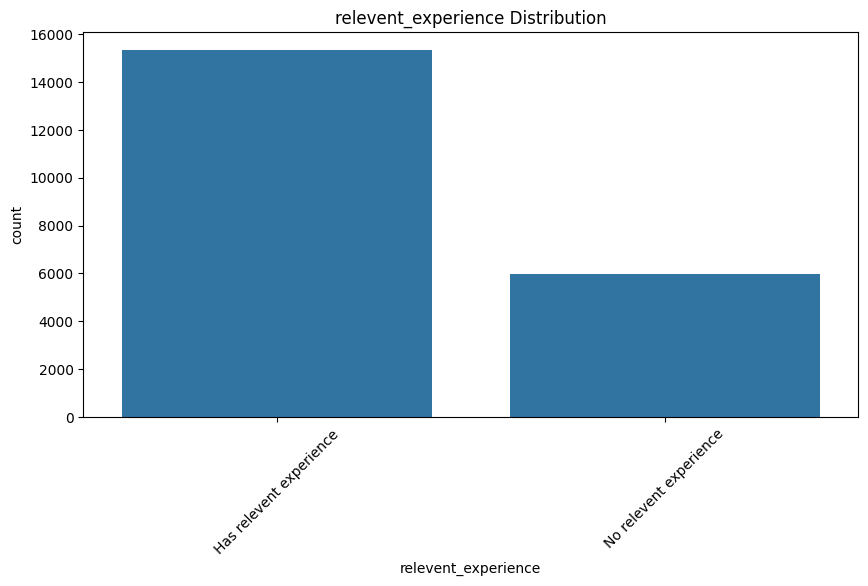

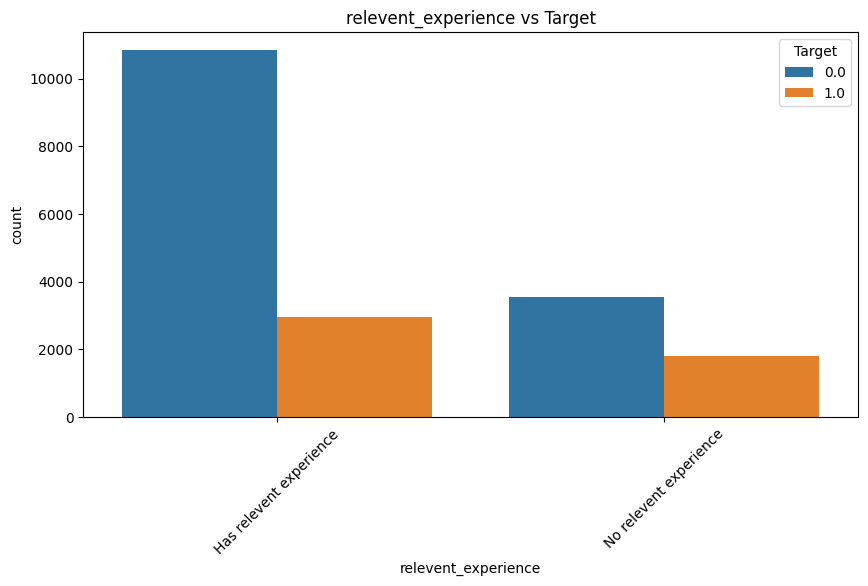

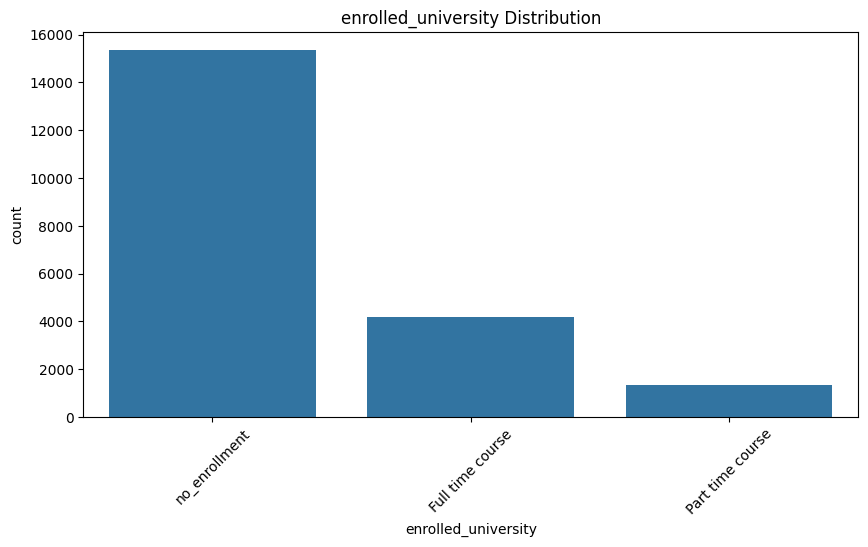

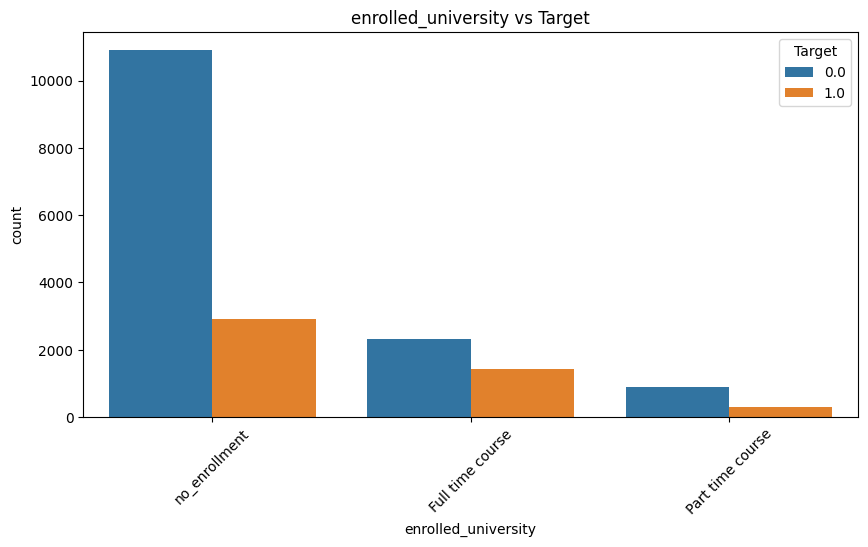

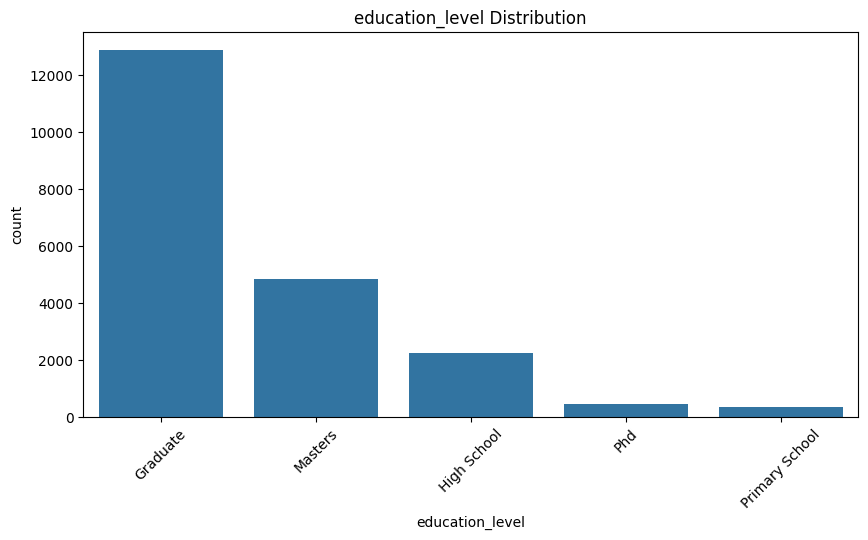

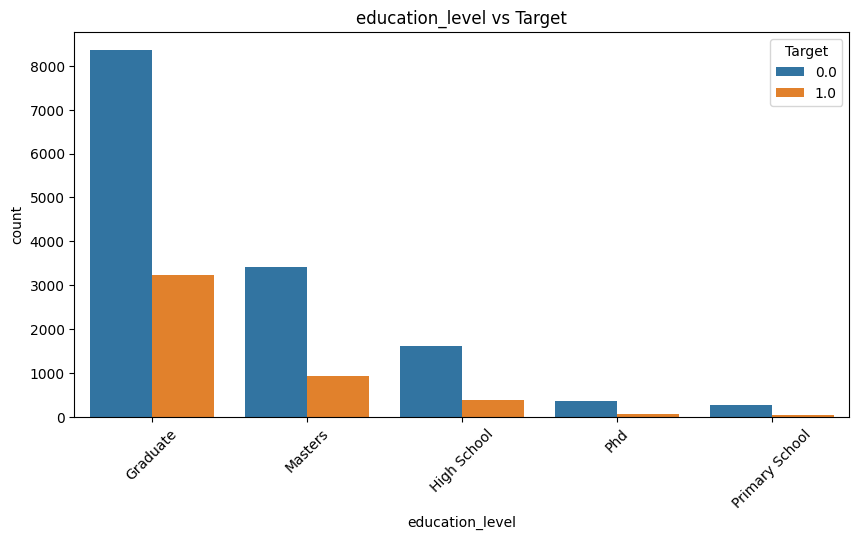

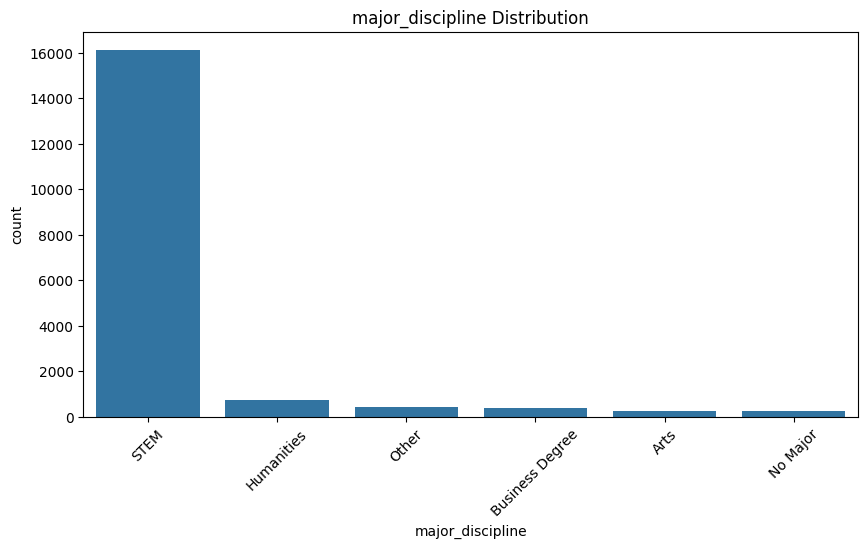

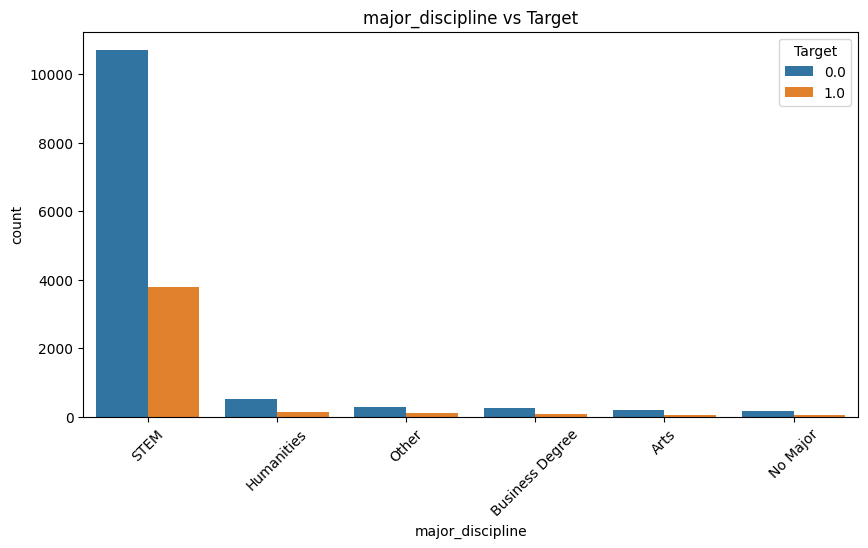

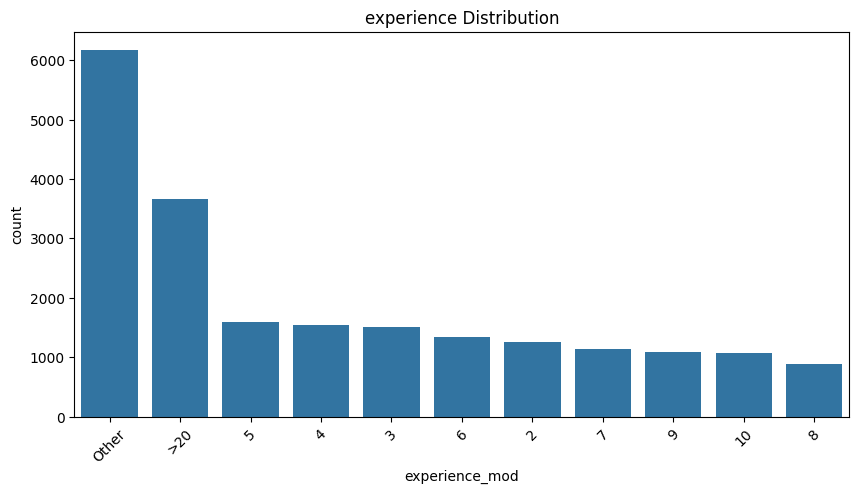

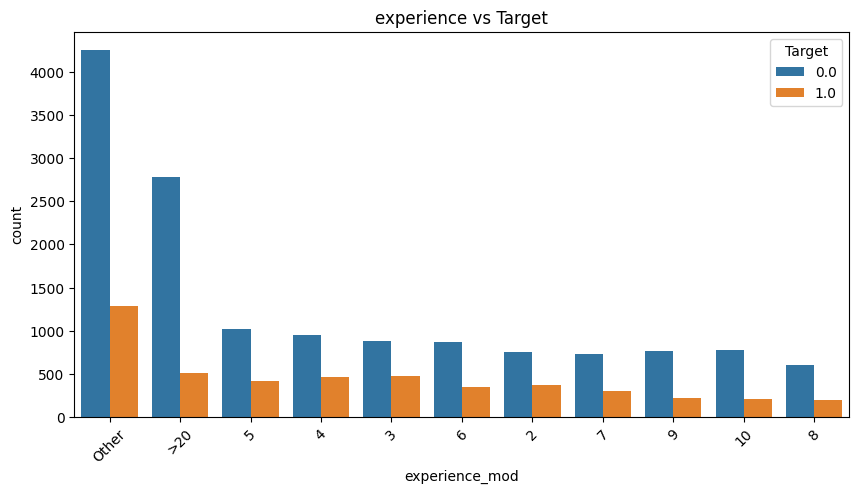

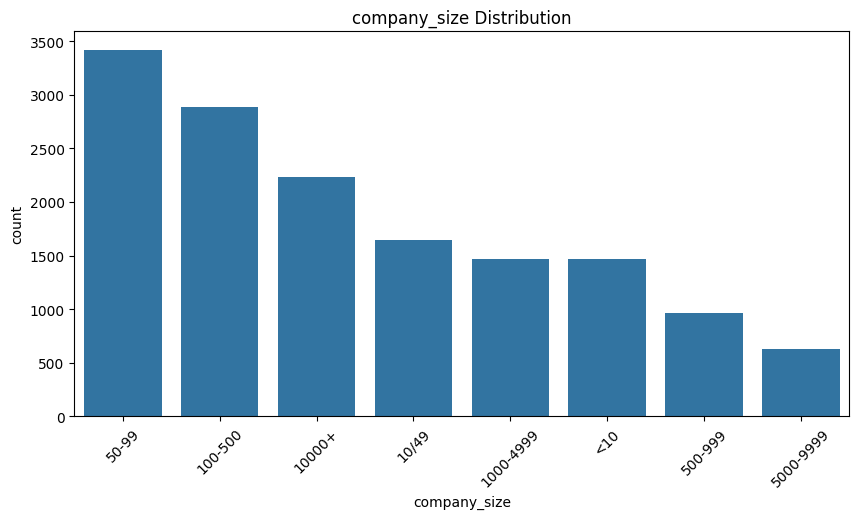

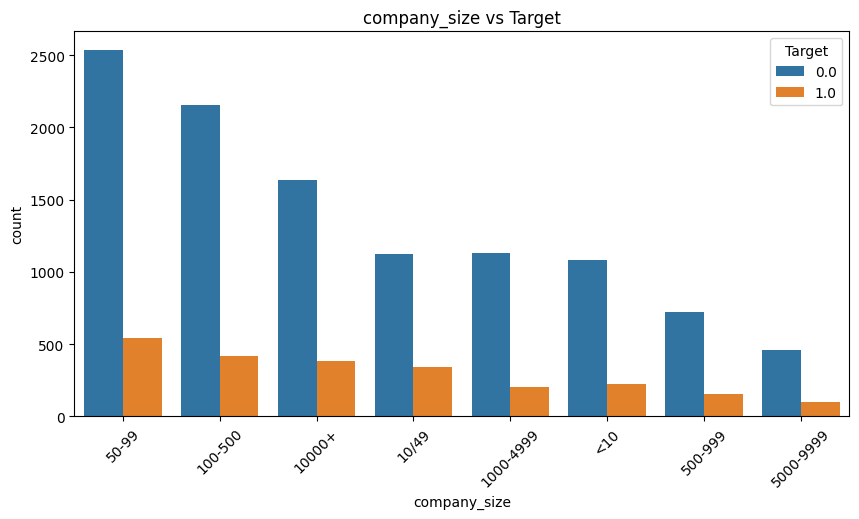

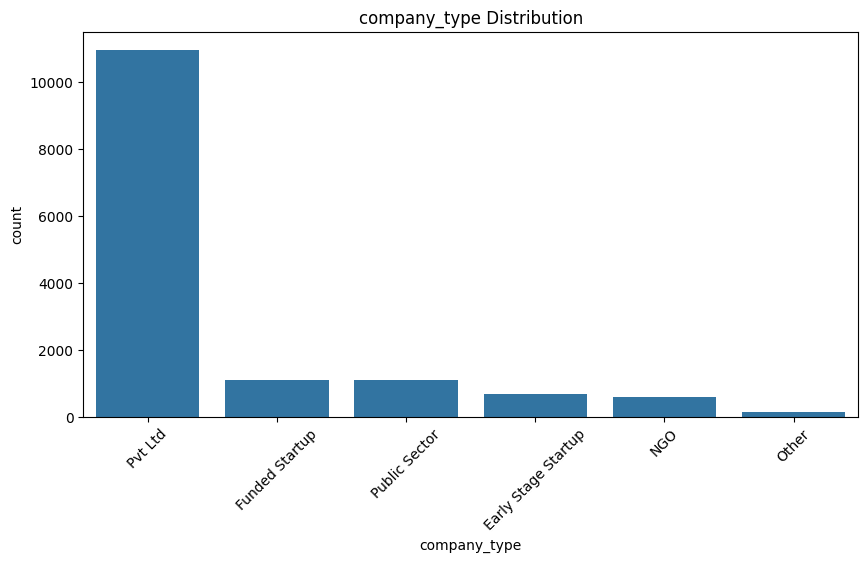

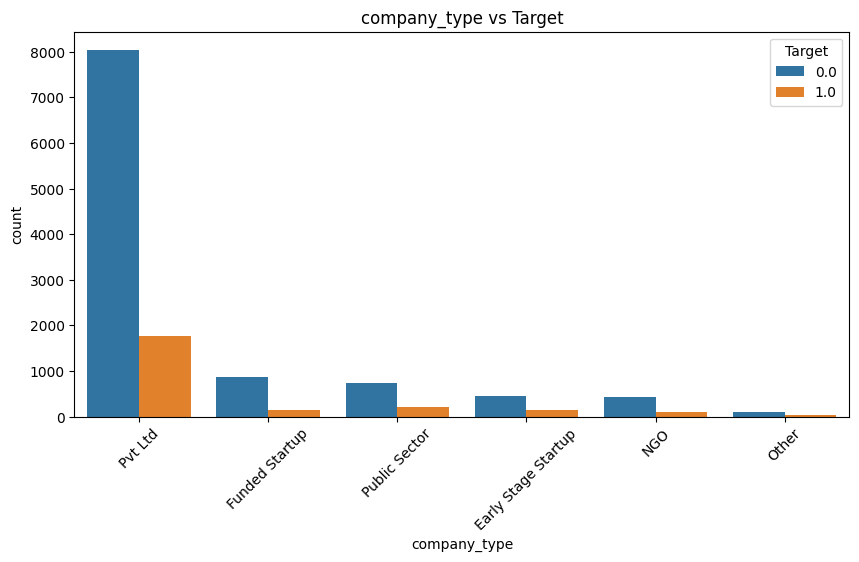

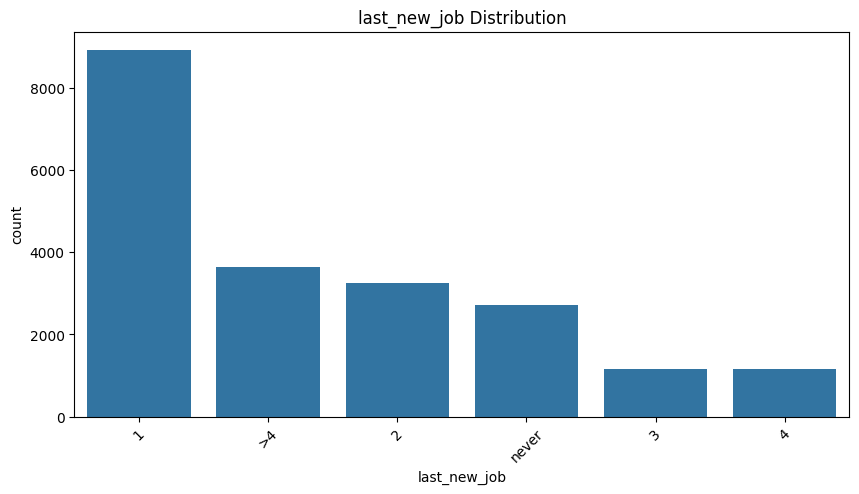

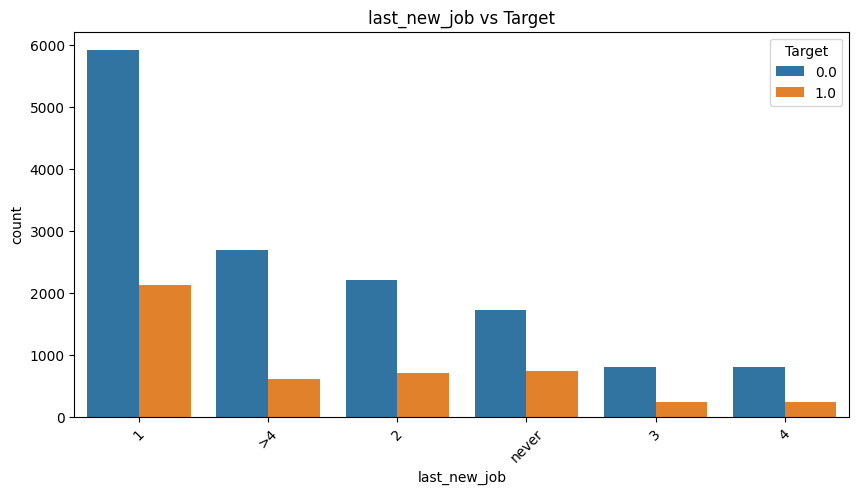

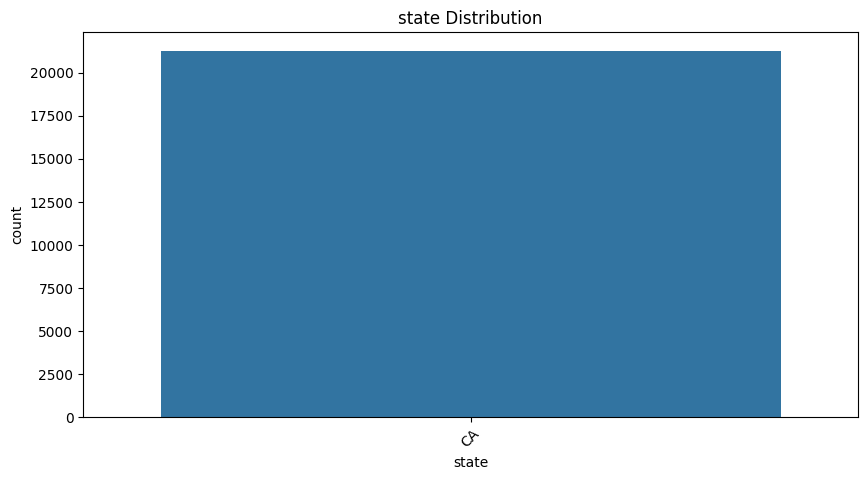

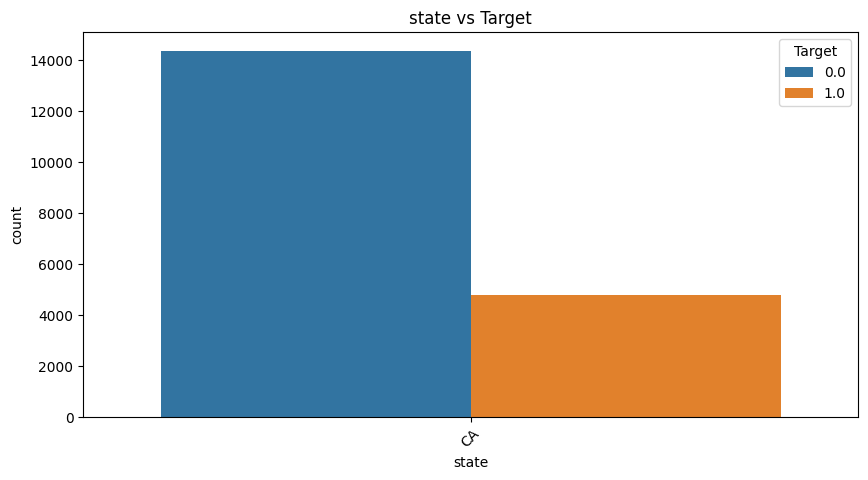

In [ ]:
# C. UNDERSTANDING CATEGORICAL ATTRIBUTES

for col in categorical_cols:
    plt.figure(figsize=(10,5))


    if df[col].nunique() > 10:  # threshold for "many categories"
        top_categories = df[col].value_counts().nlargest(10).index
        df[col + '_mod'] = df[col].where(df[col].isin(top_categories), 'Other')
        plot_col = col + '_mod'
    else:
        plot_col = col

    # Distribution plot
    sns.countplot(data=df, x=plot_col, order=df[plot_col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution")
    plt.show()

    # Distribution vs target
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=plot_col, hue='target', order=df[plot_col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Target")
    plt.legend(title='Target')
    plt.show()



# Interpretation
- Based on the city distribution, there is a number of cities that dominate, showing a skewed right graph. There is a lot of cities that only appear once.
- We clean up this graph a lot by categorizing a lot of the one to few named cities into an "other" category. That would fix cluster.

- The `state` feature contains a large number of categories, with many states having relatively few observations. This creates a high-cardinality categorical feature and may make the feature less useful for a future predictive model without additional preprocessing.

- Because `city` and `state` both provide geographic information, `state` may provide limited additional information beyond the city-related features. Therefore, I would consider removing `state` during feature selection, especially if it does not show a meaningful relationship with the target variable. Alternatively, states with very few observations could be grouped into an "Other" category.

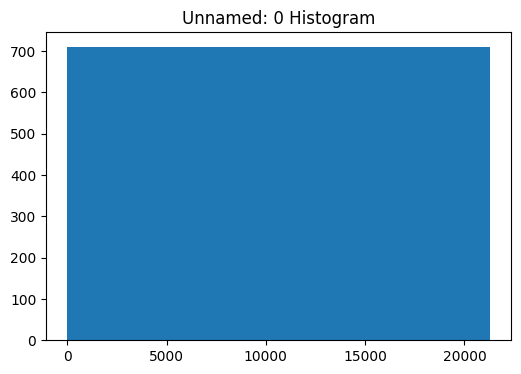

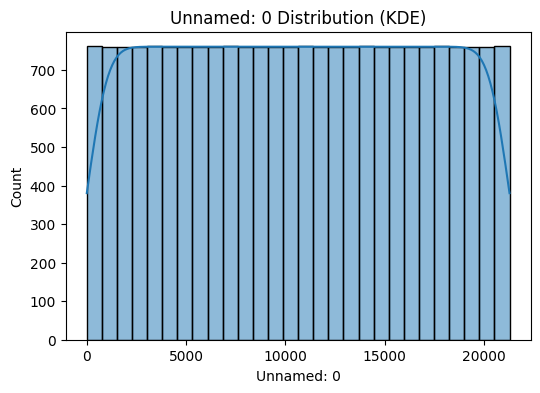

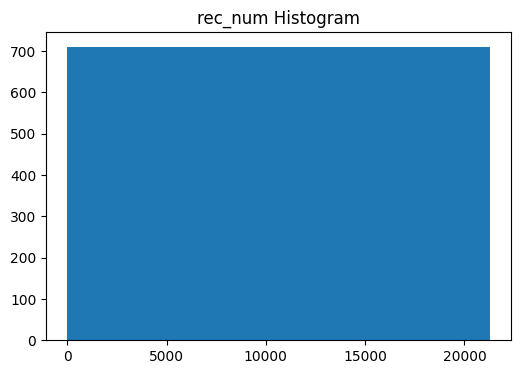

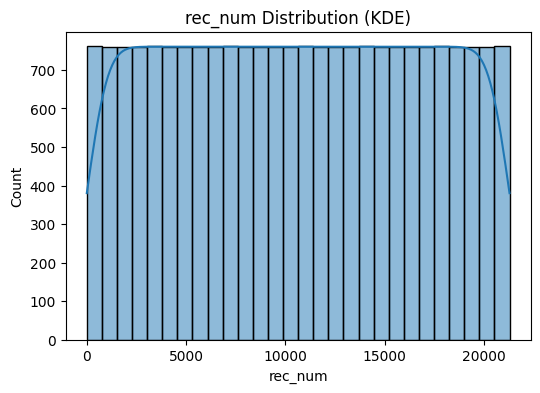

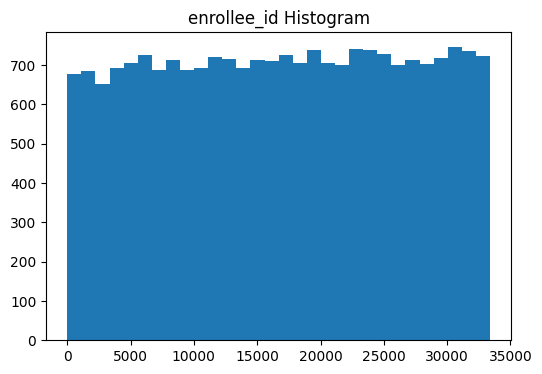

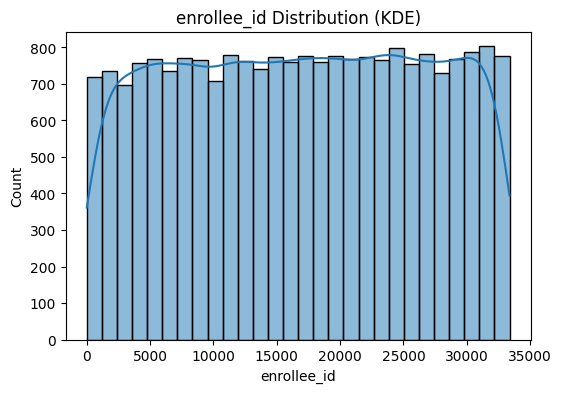

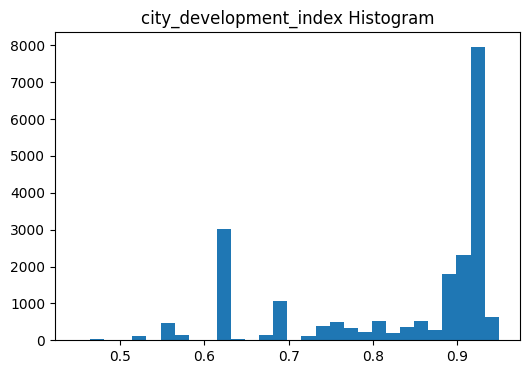

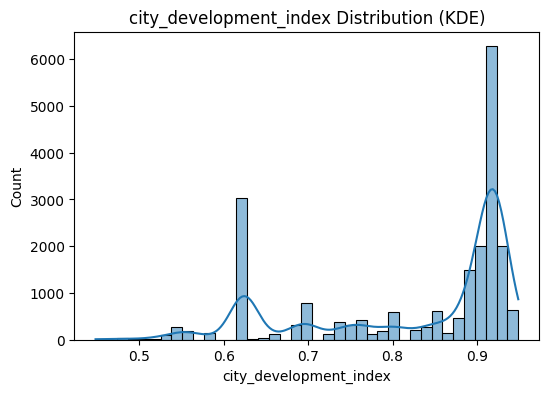

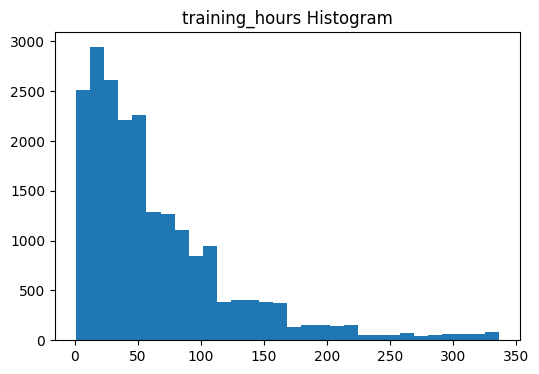

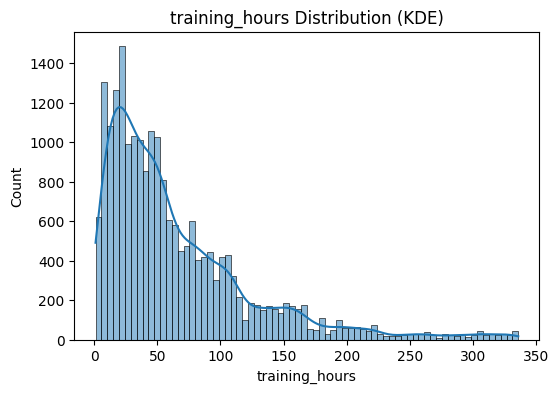

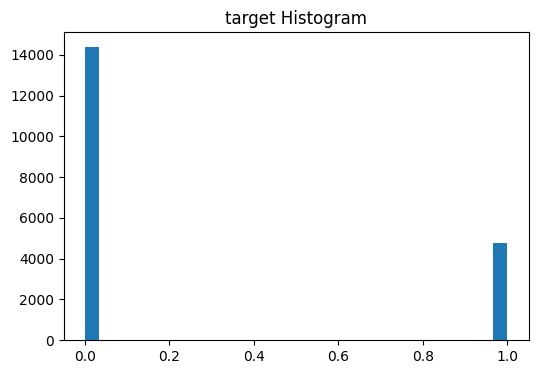

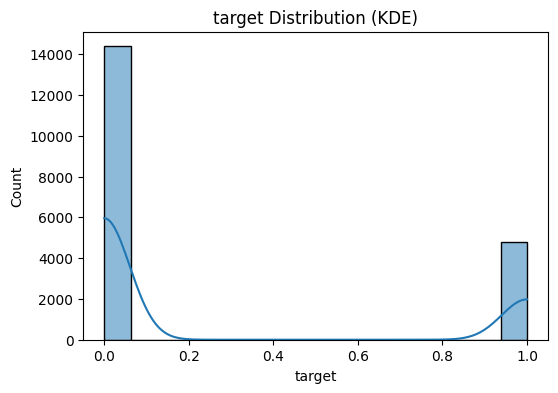

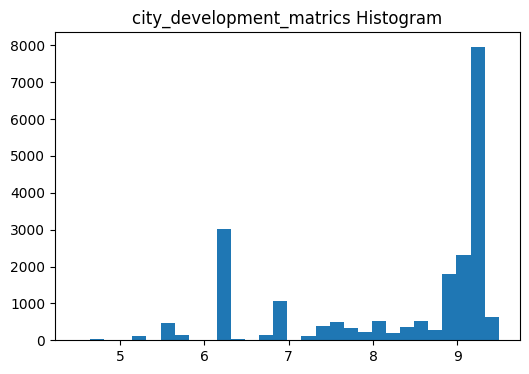

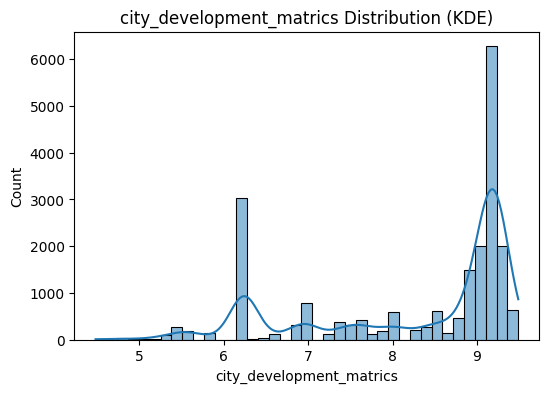

In [ ]:
# D. UNDERSTANDING NUMERICAL ATTRIBUTES

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"{col} Histogram")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"{col} Distribution (KDE)")
    plt.show()




# Interpretation

The numerical distributions show several interesting patterns.

The `enrollee_id` and `rec_num` variables have approximately uniform distributions. Since these variables primarily function as identifiers or record numbers rather than meaningful characteristics of candidates, they are unlikely to provide useful predictive information. These columns should therefore be considered for removal before future modeling.

The `city_development_index` shows a bimodal distribution, meaning that the observations appear to cluster around two different ranges of development levels. This may indicate that candidates are concentrated in two different groups of cities with different levels of development.

The `city_development_matrix` shows a distribution similar to `city_development_index`. The similarity between these two variables suggests that they may contain overlapping information. Their relationship should therefore be examined further using correlation analysis before deciding whether both features are necessary.

The `training_hours` distribution is right-skewed. Most candidates completed a relatively small number of training hours, while a smaller number completed substantially more hours. This creates a long right tail and indicates that a transformation such as a logarithmic transformation could potentially be considered before future modeling.

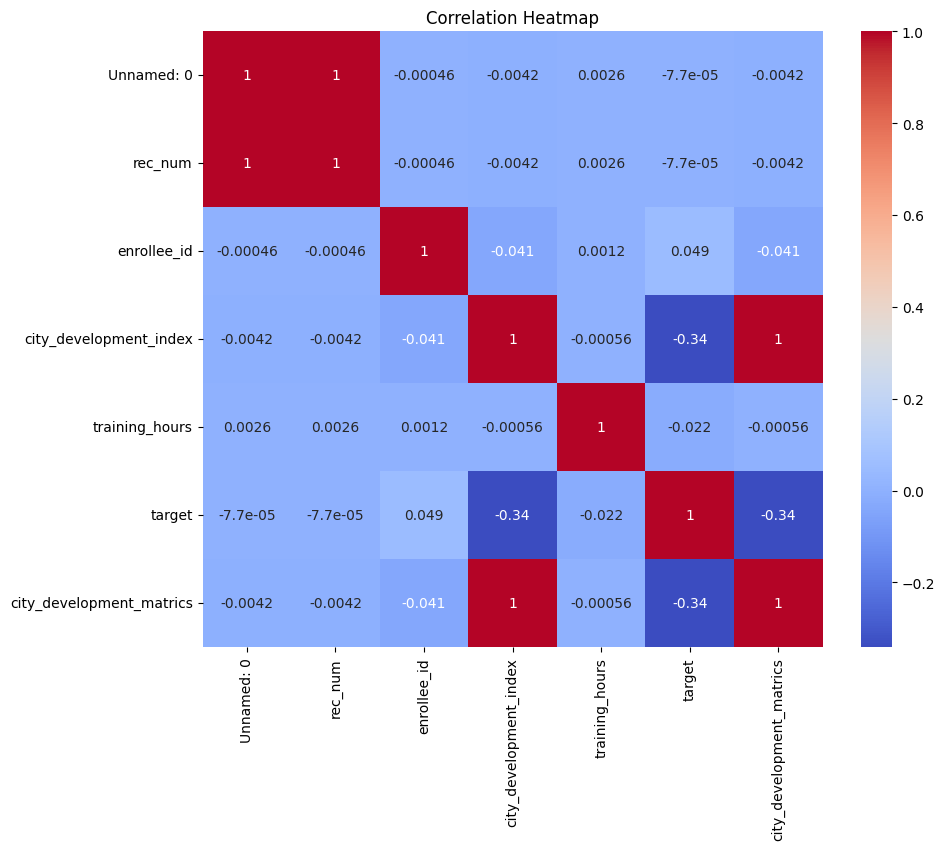

In [ ]:
# E. CORRELATION ANALYSIS

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


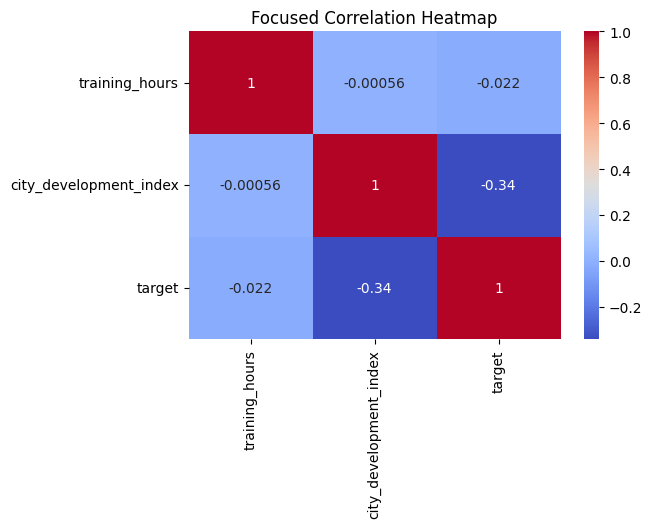

In [ ]:
# Focused correlation heatmap
selected_cols = ['training_hours', 'city_development_index', 'target']

plt.figure(figsize=(6,4))
sns.heatmap(df[selected_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Focused Correlation Heatmap")
plt.show()

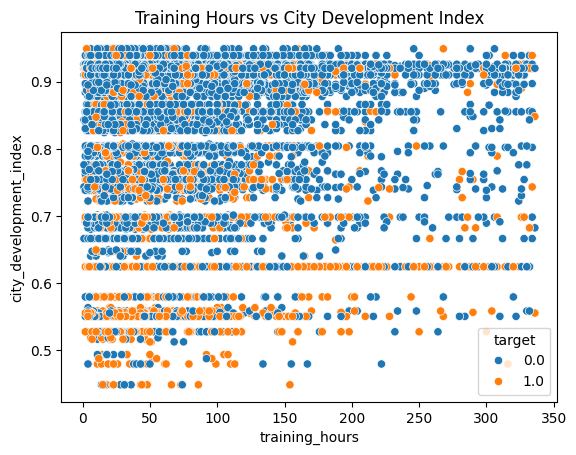

In [ ]:
for col in numerical_cols:
    if col != 'target':
        plt.figure(figsize=(7,5))
        sns.boxplot(data=df, x='target', y=col)
        plt.title(f"{col} vs Target")
        plt.show()

# Interpretation of Numerical Features vs Target

The numerical features do not show strong separation between the two target classes. However, `city_development_index` shows some differences between candidates who are and are not looking for a job change. Candidates from cities with different development levels appear to have somewhat different target distributions.

`training_hours` also shows substantial variation within both target groups, suggesting that training hours alone may not strongly distinguish candidates who are looking for a job change from those who are not.

The identifier variables, such as `enrollee_id` and `rec_num`, do not provide meaningful information about the target and should be removed before modeling.

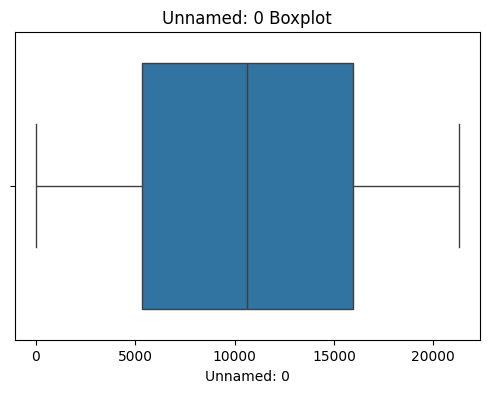

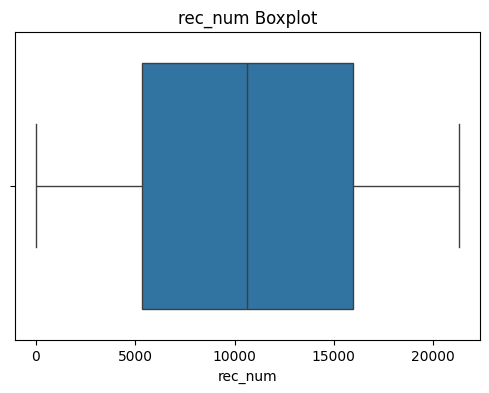

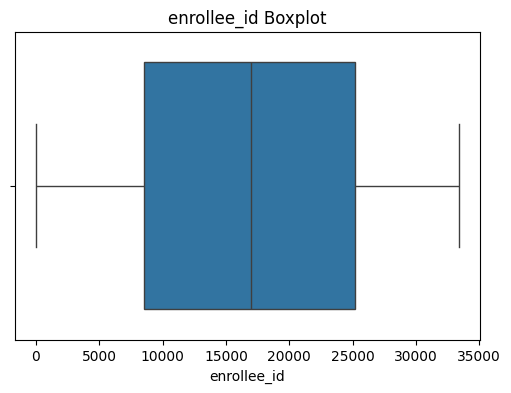

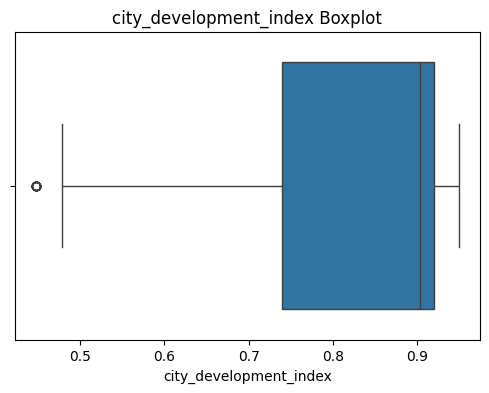

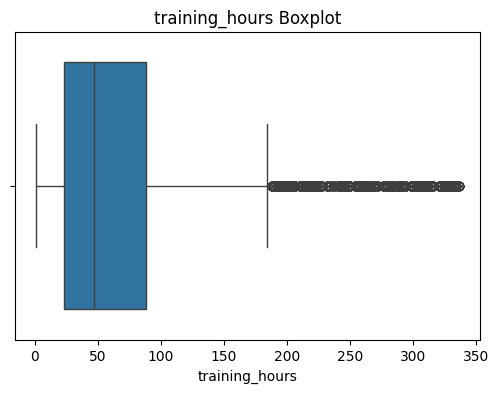

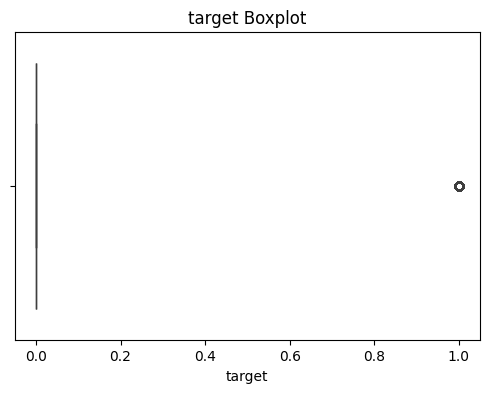

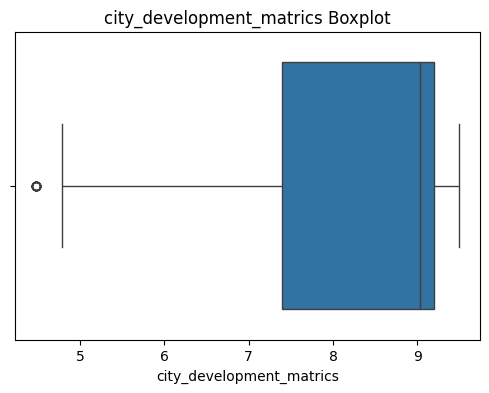

In [ ]:
# F. OUTLIERS

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

# Interpretation

The boxplots show that `training_hours` contains a substantial number of high-value observations, indicating a right-skewed distribution with potential outliers.

The city development variables also contain potential outliers. In particular, `city_development_index` and `city_development_matrix` have observations that fall relatively far from the central portion of their distributions. These observations may represent candidates from cities with unusually low or high development levels rather than errors in the data.

Therefore, these observations should not automatically be removed. Before removing them, their values should be investigated to determine whether they represent legitimate cities. If they are valid observations, they should generally be retained, although transformations or robust statistical methods could be considered for future modeling.

In [ ]:
# G. EXPERIENCE CATEGORIZATION


df['experience'].unique()


array(['>20', '15', '5', '<1', '11', '13', '7', '17', '2', '16', '1', '4',
       '10', '14', '18', '19', '12', '3', '6', '9', '8', '20', nan],
      dtype=object)

In [ ]:
def experience_category(x):
    try:
        x = int(x)
        if x <= 2:
            return 0
        elif x <= 6:
            return 1
        else:
            return 2
    except:
        return np.nan

df['experience_cat'] = df['experience'].apply(experience_category)
df[['experience', 'experience_cat']].head()


,experience,experience_cat
0,>20,NaN
1,15,2.0
2,5,1.0
3,<1,NaN
4,>20,NaN


# Categorization Logic
- Group 0: Entry-level (0–2 years)
- Group 1: Mid-level (3–6 years)
- Group 2: Senior-level (7+ years)

# H. SUMMARY AND DISCUSSION

The exploratory data analysis revealed several important characteristics of the dataset that should be considered before developing a predictive model.

### Missing Values

Several features contain missing values, with `company_type`, `company_size`, `gender`, `education_level`, `major_discipline`, and other candidate information containing varying amounts of missing data. The missingness patterns suggest that some variables may be missing together. In particular, `company_size` and `company_type` show a strong relationship in their missingness patterns, suggesting that candidates who did not provide information about their company may have omitted both fields.

The `target` variable should also be checked for missing values. Since the target is the variable that a future supervised learning model would attempt to predict, records with missing target values cannot be directly used for supervised training and would need to be removed or otherwise handled.

For `company_size` and `company_type`, removing all records with missing values may unnecessarily reduce the dataset. Instead, missing values could potentially be represented as an "Unknown" category for categorical variables or imputed using an appropriate strategy.

### Gender

The `gender` feature contains missing values and an uneven distribution across categories. Because of the missing values and potentially limited predictive value, this feature should be evaluated carefully before modeling. Depending on the modeling objective and fairness considerations, missing gender values could be grouped into an "Unknown" category rather than automatically removing those records.

### Identifier Columns

`enrollee_id` and `rec_num` behave primarily as identifiers and show approximately uniform distributions. These variables do not represent meaningful candidate characteristics and should be removed before developing a predictive model because they are unlikely to generalize to new candidates.

### City Development Features

`city_development_index` and `city_development_matrix` have similar distributions and show a strong correlation with one another. This indicates that the two variables may contain redundant information. Therefore, one of these columns should be removed before modeling to reduce redundancy and potential multicollinearity.

The city development variables also contain potential outliers. These observations should not automatically be removed because they may represent legitimate cities with unusually high or low development values. Their validity should be investigated before making a decision.

### State

The `state` variable contains geographic information with potentially many categories and relatively small groups. Because it may provide limited additional information compared with the other geographic features, I would consider removing `state` during feature selection. If it is retained, rare states could potentially be grouped into an "Other" category.

### Numerical Features

`training_hours` is right-skewed, with most candidates having relatively low training hours and a smaller number having substantially higher values. A transformation such as a logarithmic transformation could be considered before modeling.

The `city_development_index` and `city_development_matrix` distributions are approximately bimodal, suggesting that candidates may be concentrated in two different groups of city development levels.

### Class Imbalance

The distribution of the `target` variable should be examined before modeling. If one class is substantially more common than the other, the dataset may require rebalancing. Possible approaches include random oversampling, random undersampling, SMOTE, or using class weights in the machine learning algorithm.

However, rebalancing should only be performed after splitting the data into training and testing sets. Resampling should be applied to the training data rather than the entire dataset to avoid data leakage.

### Experience

The `experience` feature was categorized into three groups:

- 0: Entry-level (0–2 years)
- 1: Mid-level (3–6 years)
- 2: Senior-level (7+ years)

This transformation reduces the number of distinct experience values and creates broader career-level categories that may be easier for a model to interpret.

### Recommended Next Steps

Before developing a predictive model, I would:

1. Remove `enrollee_id` and `rec_num` because they are identifier variables.
2. Investigate and handle missing values, particularly in `target`, `company_size`, `company_type`, and `gender`.
3. Remove either `city_development_index` or `city_development_matrix` because of their strong correlation and similar information.
4. Consider removing `state` because of its high cardinality and potentially limited additional predictive value.
5. Consider transforming the right-skewed `training_hours` feature.
6. Investigate potential outliers rather than automatically removing them.
7. Examine the target class distribution and apply an appropriate rebalancing strategy if substantial class imbalance exists.
8. Split the data into training and testing sets before applying resampling or other preprocessing steps.
9. Perform feature selection and evaluate the resulting features using an appropriate machine learning model.